# Survey Data Analysis
The data analyzed comes from the survey developed and published on Qualtrics. This notebook aims to extract and visualize the raw data.

In [278]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Cleaning raw data

In [279]:
df = pd.read_csv("survey-data-raw.csv")
# Selecting the necessary columns for analysis, excluding personal or sensitive data
# Full data will not be shown for privacy reasons
columns = [
    "Q4",
    "Q5",
    "Q5_7_TEXT",
    "Q6",
    "Q7",
    "Q9",
    "Q9_9_TEXT",
    "Q10",
    "Q11",
    "Q12",
    "Q13",
    "Q14",
    "Q15",
    "Q16",
    "Q17",
]
df = df[columns].drop(1)
df = df.reset_index().drop(["index"], axis=1)
display(df.head())

,Q4,Q5,Q5_7_TEXT,Q6,Q7,Q9,Q9_9_TEXT,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17
0,Which country do you currently reside in?,What is your current occupation? - Selected Ch...,What is your current occupation? - Other (plea...,How frequently do you use the internet?,How would you rate the overall quality of inte...,For which of the following purposes do you reg...,For which of the following purposes do you reg...,To what extent has internet access helped you ...,Do you use the internet to network with profes...,"Have you ever used the internet to start, mana...",How essential is the internet for performing y...,Have you ever used the internet to search or a...,"In your opinion, how important is internet acc...",Do you use the internet for personal financial...,How much do you rely on the internet for manag...
1,Netherlands,Student,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,"Yes, regularly",Yes,Very essential,Yes,Extremely important,Yes,Heavily rely on it
2,Netherlands,Student,NaN,Daily,Poor,"Online banking or financial services,Social me...",NaN,Significantly,Rarely,No,Very essential,Yes,Extremely important,Yes,Heavily rely on it
3,Netherlands,Student,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,Occasionally,Yes,I could not work without it,Yes,Very important,Yes,Rely on it to some extent
4,The Netherlands\r\n,Employed full-time,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,"Yes, regularly",Yes,I could not work without it,Yes,Extremely important,Yes,Heavily rely on it


In [280]:
# Rename columns with descriptive names
df = df.rename(
    columns={
        "Q4": "Residence Country",
        "Q5": "Occupation",
        "Q5_7_TEXT": "Occupation_Text",
        "Q6": "Internet_Usage_Freq",
        "Q7": "Internet_Quality",
        "Q9": "Internet_Usage_Purpose",
        "Q9_9_TEXT": "Internet_Usage_Purpose_Text",
        "Q10": "Internet_Access_Job_Opportunities",
        "Q11": "Online_Networking",
        "Q12": "Internet_Use_Entrepreneurship",
        "Q13": "Job_Dependence_Internet",
        "Q14": "Internet_Job_Search",
        "Q15": "Job_Finding_Internet_Value",
        "Q16": "Online_Banking",
        "Q17": "Internet_Reliance_Finance",
    }
)
# Drop question row
df = df.drop(0)
display(df.head())

,Residence Country,Occupation,Occupation_Text,Internet_Usage_Freq,Internet_Quality,Internet_Usage_Purpose,Internet_Usage_Purpose_Text,Internet_Access_Job_Opportunities,Online_Networking,Internet_Use_Entrepreneurship,Job_Dependence_Internet,Internet_Job_Search,Job_Finding_Internet_Value,Online_Banking,Internet_Reliance_Finance
1,Netherlands,Student,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,"Yes, regularly",Yes,Very essential,Yes,Extremely important,Yes,Heavily rely on it
2,Netherlands,Student,NaN,Daily,Poor,"Online banking or financial services,Social me...",NaN,Significantly,Rarely,No,Very essential,Yes,Extremely important,Yes,Heavily rely on it
3,Netherlands,Student,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,Occasionally,Yes,I could not work without it,Yes,Very important,Yes,Rely on it to some extent
4,The Netherlands\r\n,Employed full-time,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,"Yes, regularly",Yes,I could not work without it,Yes,Extremely important,Yes,Heavily rely on it
5,united kingdom\r\n,Student,NaN,Daily,Good,"Online banking or financial services,Social me...",NaN,Slightly,Occasionally,Yes,Very essential,Yes,Very important,Yes,Rely on it to some extent


In [281]:
# Clean and capitalize country names
df["Residence Country"] = df["Residence Country"].str.strip().str.title()

# Standardize and replace shared country names
country_names = df["Residence Country"].unique()
print(country_names)
name_map = {
    "Nl": "Netherlands",
    "The Netherlands": "Netherlands",
    "România": "Romania",
}
df["Residence Country"] = df["Residence Country"].replace(name_map)

['Netherlands' 'The Netherlands' 'United Kingdom' 'Nl' 'China' 'Romania'
 'Belgium' 'Poland' 'Israel' 'France' 'Thailand' 'Germany' 'Latvia'
 'România' 'Canada' 'Argentina' 'Italy' 'United States' nan]


In [282]:
# Check for text values and replace them in main columns
occupation_values = df["Occupation_Text"].unique()
print(occupation_values)
df["Occupation"] = df.apply(
    lambda row: row["Occupation_Text"]
    if row["Occupation"] == "Other (please specify):"
    else row["Occupation"],
    axis=1,
)
name_map = {
    "Student and part time": "Student/Employed part-time",
    "Student, Employed part-time": "Student/Employed part-time",
    "Employed part-time student ": "Student/Employed part-time",
}
df["Occupation"] = df["Occupation"].replace(name_map)

internet_purpose_values = df["Internet_Usage_Purpose_Text"].unique()
print(internet_purpose_values)

[nan 'Student, Employed part-time' 'Student and part time'
 'Employed part-time student ']
[nan]


In [283]:
# Save csv
df.to_csv("survey-data-cleaned.csv", index=False)

### Analyze and Visualize Data

In [284]:
df = pd.read_csv("survey-data-cleaned.csv")
df.head()

,Residence Country,Occupation,Occupation_Text,Internet_Usage_Freq,Internet_Quality,Internet_Usage_Purpose,Internet_Usage_Purpose_Text,Internet_Access_Job_Opportunities,Online_Networking,Internet_Use_Entrepreneurship,Job_Dependence_Internet,Internet_Job_Search,Job_Finding_Internet_Value,Online_Banking,Internet_Reliance_Finance
0,Netherlands,Student,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,"Yes, regularly",Yes,Very essential,Yes,Extremely important,Yes,Heavily rely on it
1,Netherlands,Student,NaN,Daily,Poor,"Online banking or financial services,Social me...",NaN,Significantly,Rarely,No,Very essential,Yes,Extremely important,Yes,Heavily rely on it
2,Netherlands,Student,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,Occasionally,Yes,I could not work without it,Yes,Very important,Yes,Rely on it to some extent
3,Netherlands,Employed full-time,NaN,Daily,Excellent,"Online banking or financial services,Social me...",NaN,Significantly,"Yes, regularly",Yes,I could not work without it,Yes,Extremely important,Yes,Heavily rely on it
4,United Kingdom,Student,NaN,Daily,Good,"Online banking or financial services,Social me...",NaN,Slightly,Occasionally,Yes,Very essential,Yes,Very important,Yes,Rely on it to some extent


#### 1. Visualizing the different purposes for Internet usage

##### 1.1 General usage

In [285]:
# Remove parantheses with examples and split multiple choice answer into separate values
df["Internet_Usage_Purpose"] = (
    df["Internet_Usage_Purpose"].str.replace(r"\(.*?\)", "", regex=True).str.split(",")
)

# Explode values for individual count
purpose_data = df["Internet_Usage_Purpose"].explode().str.strip().value_counts()
display(purpose_data)

Internet_Usage_Purpose
Communication                           68
Social media or online communities      63
Online banking or financial services    59
Studying or online courses              52
Accessing public services               47
E-commerce                              41
Using internet as a part of your job    38
Searching or applying for jobs          33
Entertainment                            1
Name: count, dtype: int64

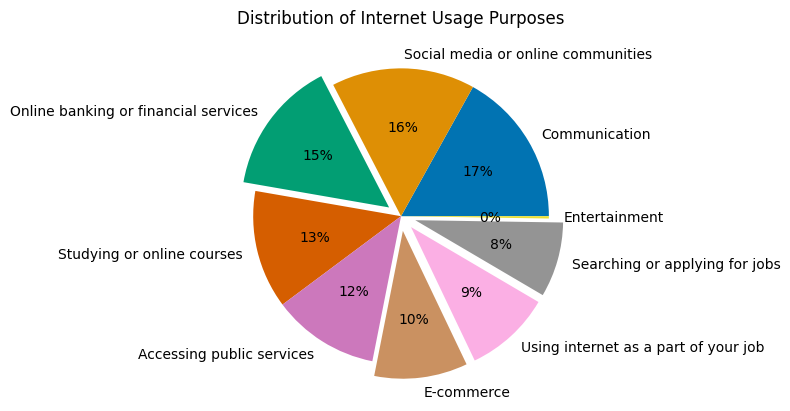

In [286]:
# Set label for each slice
labels = [
    "Communication",
    "Social media or online communities",
    "Online banking or financial services",
    "Studying or online courses",
    "Accessing public services",
    "E-commerce",
    "Using internet as a part of your job",
    "Searching or applying for jobs",
    "Entertainment",
]
palette_color = sns.color_palette("colorblind")
# Emphasize purposes related to economic activities
explode = [0, 0, 0.1, 0, 0, 0.1, 0.1, 0.1, 0]
plt.pie(
    purpose_data, labels=labels, colors=palette_color, explode=explode, autopct="%.0f%%"
)
plt.title("Distribution of Internet Usage Purposes")
plt.show()

##### 1.2 Usage per occupation

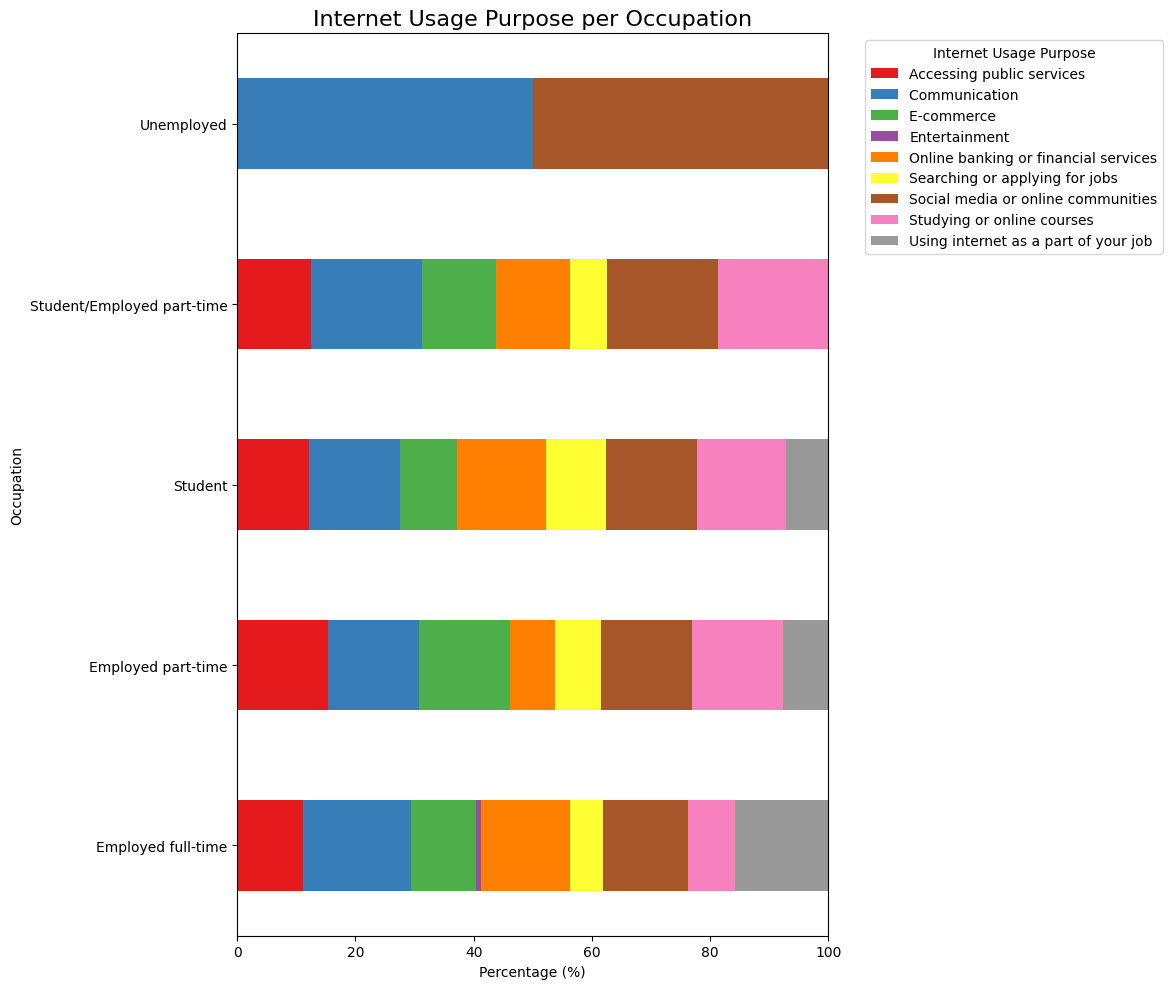

In [ ]:
# Explode list of usage purposes
df = df.explode("Internet_Usage_Purpose")

# Remove prefer not to say from occupations
df = df[df["Occupation"] != "Prefer not to say"]

# Group and count occupation with purposes
data_counts = (
    df.groupby(["Occupation", "Internet_Usage_Purpose"])
    .size()
    .reset_index(name="Count")
)

# Rotate table for visualization
data_counts = data_counts.pivot_table(
    index="Occupation", columns="Internet_Usage_Purpose", values="Count", fill_value=0
)

# Convert data to percentages
data_percent = data_counts.div(data_counts.sum(axis=1), axis=0) * 100

# Plot bar chart
ax = data_percent.plot(kind="barh", stacked=True, figsize=(12, 10), colormap="Set1")

plt.title("Internet Usage Purpose per Occupation", fontsize=16)
plt.xlabel("Percentage (%)")
plt.ylabel("Occupation")
plt.xlim(0, 100)
plt.legend(title="Internet Usage Purpose", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 2. Visualizing reliance on Internet for completing jobs

##### 2.1 Overall Pie Chart

Job_Dependence_Internet
Very essential                 31
I could not work without it    17
Somewhat essential             10
Not essential                   9
Name: count, dtype: int64

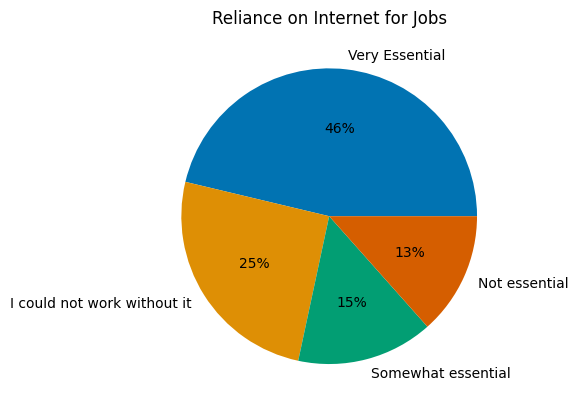

In [287]:
reliance_counts = df["Job_Dependence_Internet"].dropna().value_counts()
display(reliance_counts)

# Set label for each slice
labels = [
    "Very Essential",
    "I could not work without it",
    "Somewhat essential ",
    "Not essential ",
]
palette_color = sns.color_palette("colorblind")
plt.pie(reliance_counts, labels=labels, colors=palette_color, autopct="%.0f%%")
plt.title("Reliance on Internet for Jobs")
plt.show()

##### 2.2 Bar Chart per Country

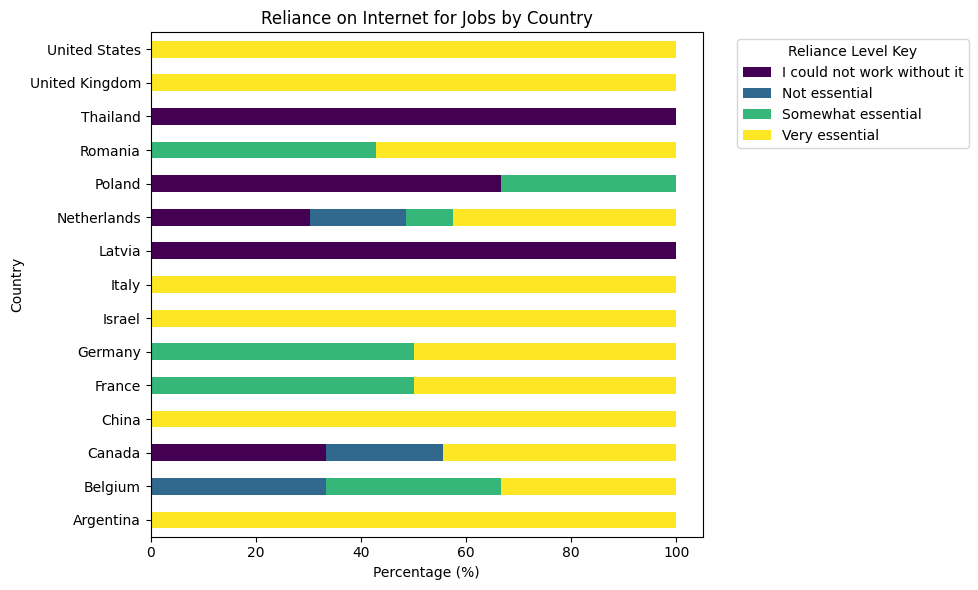

In [288]:
# Group responses and normalize values
job_reliance_per_country = (
    df.groupby(["Residence Country", "Job_Dependence_Internet"])
    .size()
    .unstack(fill_value=0)
)

# Convert values to percentages
score_percentage = (
    job_reliance_per_country.div(job_reliance_per_country.sum(axis=1), axis=0) * 100
)

# Plot
score_percentage.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="viridis")
plt.xlabel("Percentage (%)")
plt.ylabel("Country")
plt.title("Reliance on Internet for Jobs by Country")
plt.legend(title="Reliance Level Key", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 3. Visualizing the use of Internet for job searching

In [289]:
reliance_counts = df["Internet_Job_Search"].value_counts()
display(reliance_counts)

Internet_Job_Search
Yes    63
No      4
Name: count, dtype: int64

##### 3.1 Overall chart

Job_Finding_Internet_Value
Extremely important     29
Very important          21
Moderately important     7
Slightly important       3
Not at all important     1
Name: count, dtype: int64

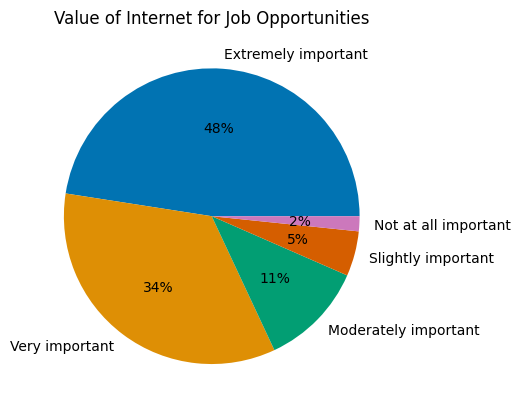

In [290]:
reliance_counts = df["Job_Finding_Internet_Value"].value_counts()
display(reliance_counts)

# Set label for each slice
labels = [
    "Extremely important",
    "Very important",
    "Moderately important",
    "Slightly important",
    "Not at all important",
]
palette_color = sns.color_palette("colorblind")
plt.pie(reliance_counts, labels=labels, colors=palette_color, autopct="%.0f%%")
plt.title("Value of Internet for Job Opportunities")
plt.show()

##### 3.2 Plot of Internet value per Occupation

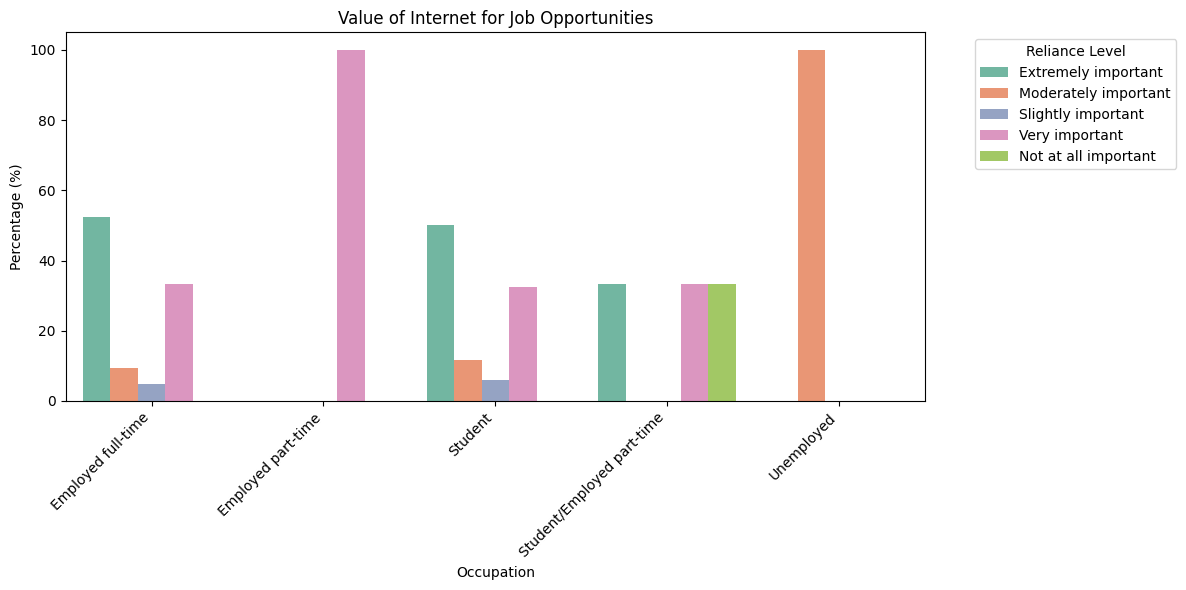

In [291]:
# Group data and count values
job_finding_data = (
    df.groupby(["Occupation", "Job_Finding_Internet_Value"])
    .size()
    .reset_index(name="Count")
)

# Normalize values and find percentage
score = job_finding_data.groupby("Occupation")["Count"].transform("sum")
job_finding_data["Percentage"] = (job_finding_data["Count"] / score) * 100

# Plot: Grouped bar chart (Occupation on x, Reliance level as hue)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=job_finding_data,
    x="Occupation",
    y="Percentage",
    hue="Job_Finding_Internet_Value",
    palette="Set2",
)

plt.title("Value of Internet for Job Opportunities")
plt.ylabel("Percentage (%)")
plt.xlabel("Occupation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Reliance Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 4. Visualizing frequency and quality of Internet usage per country

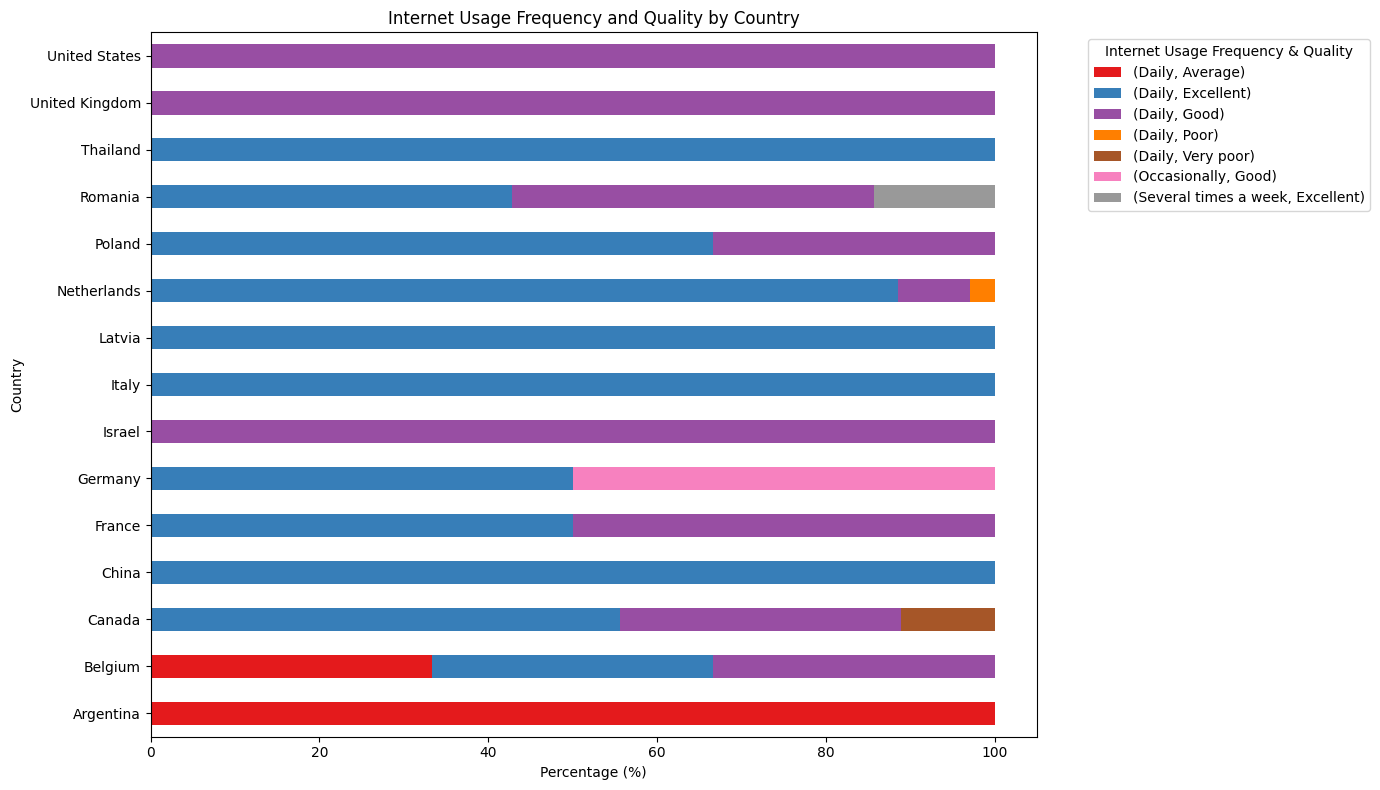

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and count data
freq_and_quality = (
    df.groupby(["Residence Country", "Internet_Usage_Freq", "Internet_Quality"])
    .size()
    .reset_index(name="Count")
)

# Normalize data and get percentages
freq_and_quality["Percentage"] = freq_and_quality.groupby("Residence Country")[
    "Count"
].transform(lambda x: x / x.sum() * 100)

# Pivot table for bar chart
pivoted_data = freq_and_quality.pivot_table(
    index="Residence Country",
    columns=["Internet_Usage_Freq", "Internet_Quality"],
    values="Percentage",
    aggfunc="sum",
    fill_value=0,
)

# Plot
pivoted_data.plot(kind="barh", stacked=True, figsize=(14, 8), colormap="Set1")

plt.title("Internet Usage Frequency and Quality by Country")
plt.xlabel("Percentage (%)")
plt.ylabel("Country")
plt.legend(
    title="Internet Usage Frequency & Quality",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

#### 5. Visualizing Internet Usage for Financial Activities

In [293]:
reliance_counts = df["Internet_Reliance_Finance"].value_counts()
display(reliance_counts)

Internet_Reliance_Finance
Heavily rely on it           40
Rely on it to some extent    20
Rarely rely on it             4
Name: count, dtype: int64

##### 5.1 Overall Chart

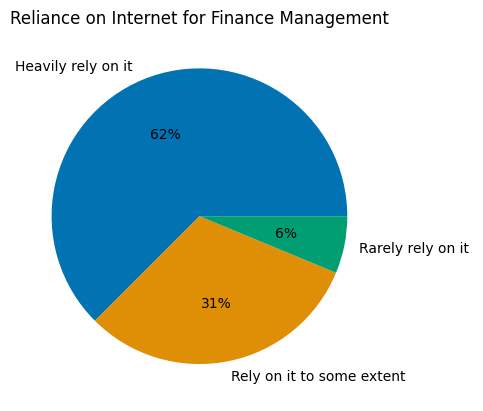

In [298]:
# Set label for each slice
labels = ["Heavily rely on it ", "Rely on it to some extent ", "Rarely rely on it "]
palette_color = sns.color_palette("colorblind")
plt.pie(reliance_counts, labels=labels, colors=palette_color, autopct="%.0f%%")
plt.title("Reliance on Internet for Finance Management")
plt.show()

##### 5.2 Plot of reliance levels per country

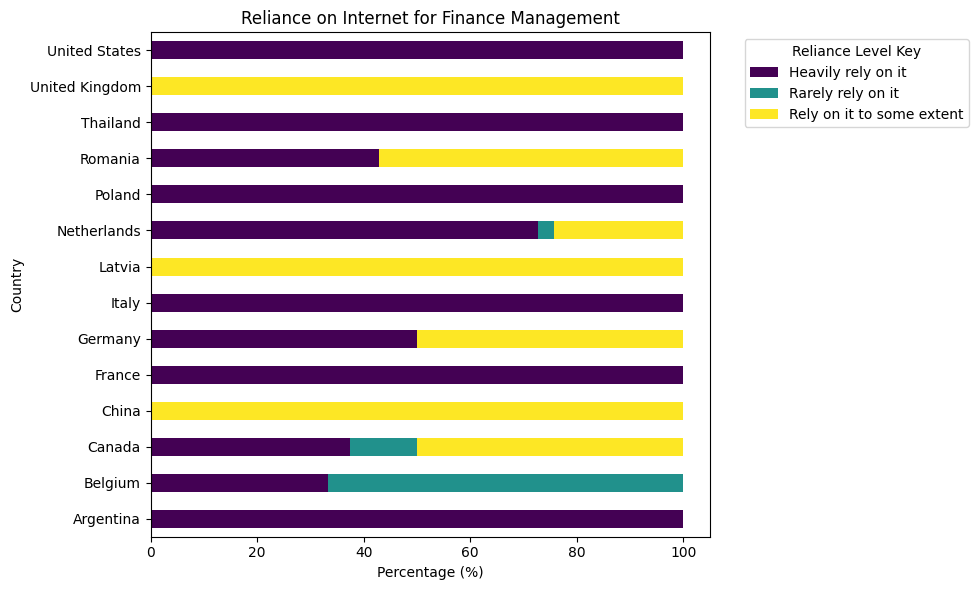

In [299]:
# Group responses and normalize values
finance_reliance_per_country = (
    df.groupby(["Residence Country", "Internet_Reliance_Finance"])
    .size()
    .unstack(fill_value=0)
)

# Convert values to percentages
score_percentage = (
    job_reliance_per_country.div(job_reliance_per_country.sum(axis=1), axis=0) * 100
)

# Plot
score_percentage.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="viridis")
plt.xlabel("Percentage (%)")
plt.ylabel("Country")
plt.title("Reliance on Internet for Finance Management")
plt.legend(title="Reliance Level Key", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()